In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")


In [3]:
base_data = pd.read_csv("processed_base_dataset.csv", parse_dates=["Date"])
alt_data  = pd.read_csv("processed_alt_dataset.csv", parse_dates=["Date"])

HORIZON = 10
QUANTILES = [0.1, 0.5, 0.9]

# Use last 10 days for final comparison plots
last_10_base = base_data.tail(10).copy()
last_10_alt  = alt_data.tail(10).copy()

print("Base shape:", base_data.shape)
print("Alt shape:", alt_data.shape)


Base shape: (1761, 30)
Alt shape: (1761, 42)


In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def pinball_loss(y_true, y_pred, q):
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))


def crps_approximation(y_true, q_preds, quantiles):
    total = 0
    for q, pred in zip(quantiles, q_preds):
        total += pinball_loss(y_true, pred, q)
    return total / len(quantiles)


def picp(y_true, lower, upper):
    inside = np.logical_and(y_true >= lower, y_true <= upper)
    return np.mean(inside)


def interval_width(lower, upper):
    return np.mean(upper - lower)


In [5]:
def get_train_test(dataset):
    
    split_index = int(len(dataset) * 0.8) 
    
    X = dataset.drop(columns=["Date"] +
                     [f"Target_t+{i}" for i in range(1, HORIZON+1)])
    
    y = dataset["Target_t+10"]  # 10-day ahead forecast
    
    X_train = X.iloc[:split_index]
    X_test  = X.iloc[split_index:]
    
    y_train = y.iloc[:split_index]
    y_test  = y.iloc[split_index:]
    
    return X_train, X_test, y_train, y_test


In [6]:
def train_qrf(X_train, y_train, X_test):
    
    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    all_tree_preds = np.array([
        tree.predict(X_test.values)
        for tree in model.estimators_
    ])
    
    quantile_preds = []
    
    for q in QUANTILES:
        preds = np.percentile(all_tree_preds, q*100, axis=0)
        quantile_preds.append(preds)
    
    return quantile_preds


In [7]:
def train_xgb_quantile(X_train, y_train, X_test, q):
    
    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    return preds


def train_xgb(X_train, y_train, X_test):
    
    quantile_preds = []
    
    for q in QUANTILES:
        preds = train_xgb_quantile(X_train, y_train, X_test, q)
        quantile_preds.append(preds)
    
    return quantile_preds


In [8]:
def train_prophet(dataset):
    
    df = dataset[["Date", "Gold_Close"]].copy()
    df.columns = ["ds", "y"]
    
    split_index = int(len(df) * 0.8)
    
    train_df = df.iloc[:split_index]
    test_df  = df.iloc[split_index:]
    
    model = Prophet(interval_width=0.8)
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)
    
    preds = forecast.iloc[-len(test_df):]
    
    lower = preds["yhat_lower"].values
    median = preds["yhat"].values
    upper = preds["yhat_upper"].values
    
    return test_df["y"].values, [lower, median, upper]


In [9]:
results = {}

for name, dataset in {"Base": base_data, "Alt": alt_data}.items():
    
    X_train, X_test, y_train, y_test = get_train_test(dataset)
    
    # QRF
    qrf_preds = train_qrf(X_train, y_train, X_test)
    
    # XGB
    xgb_preds = train_xgb(X_train, y_train, X_test)
    
    # Prophet
    y_prophet, prophet_preds = train_prophet(dataset)
    
    results[name] = {
        "y_test": y_test.values,
        "QRF": qrf_preds,
        "XGB": xgb_preds,
        "Prophet": prophet_preds
    }


10:30:40 - cmdstanpy - INFO - Chain [1] start processing
10:30:41 - cmdstanpy - INFO - Chain [1] done processing
10:30:47 - cmdstanpy - INFO - Chain [1] start processing
10:30:48 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
def plot_last_10(actual, preds, model_name, dataset_name):
    
    actual_last10 = actual[-10:]
    lower = preds[0][-10:]
    median = preds[1][-10:]
    upper = preds[2][-10:]
    
    plt.figure()
    plt.xlabel("Days")
    plt.ylabel("Gold Price")
    plt.plot(actual_last10, label="Actual")
    plt.plot(median, label="Median Forecast")
    plt.fill_between(
        range(10),
        lower,
        upper,
        alpha=0.3
    )
    
    plt.title(f"{model_name} - {dataset_name} (Last 10 Days)")
    plt.legend(loc="lower right")
    plt.show()


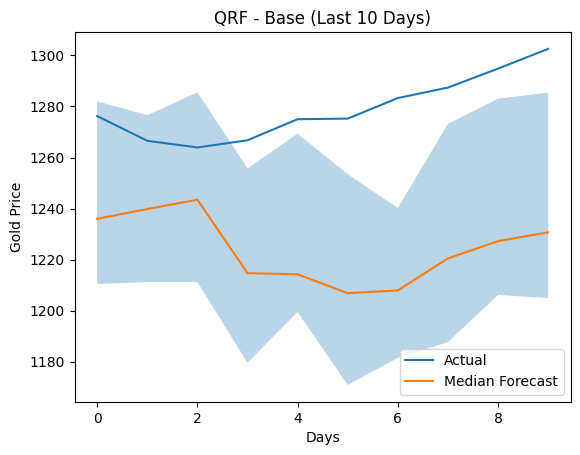

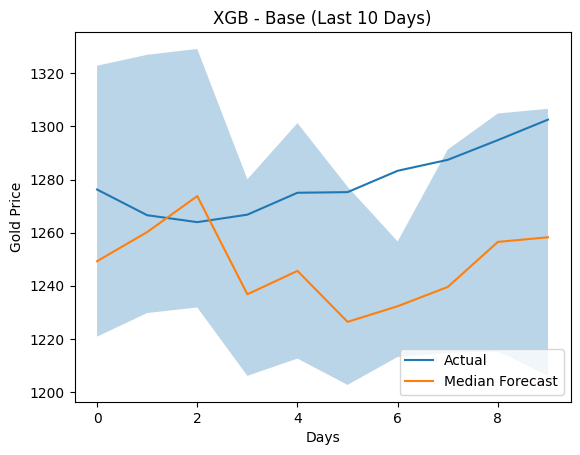

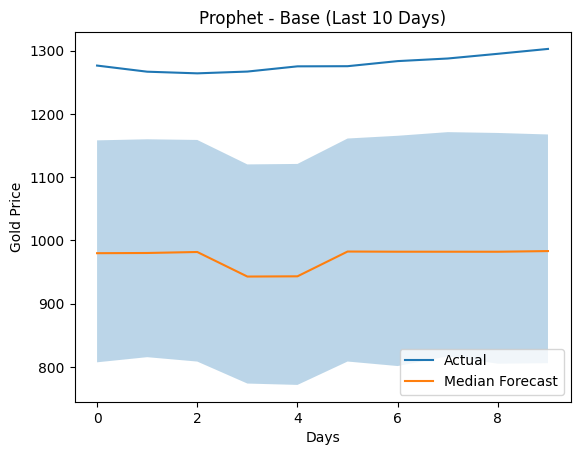

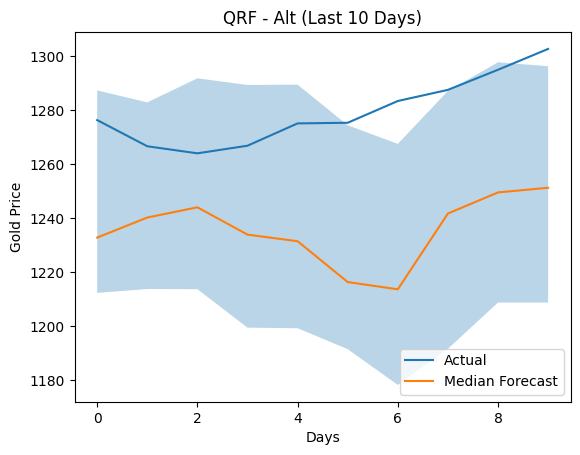

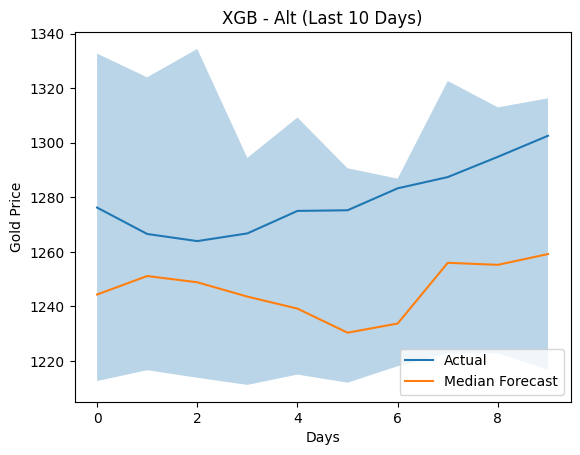

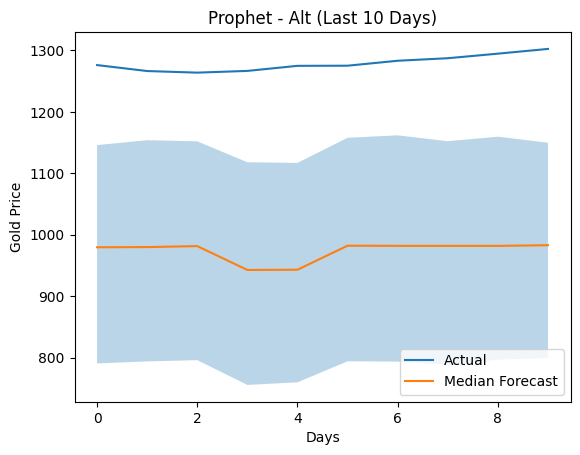

In [11]:
for dataset_name in ["Base", "Alt"]:
    
    y_test = results[dataset_name]["y_test"]
    
    for model in ["QRF", "XGB", "Prophet"]:
        
        preds = results[dataset_name][model]
        plot_last_10(y_test, preds, model, dataset_name)


In [12]:
# ============================================================
# FULL MULTI-HORIZON EVALUATION
# ============================================================

def evaluate_model(dataset, model_type, dataset_name):
    
    results = []
    
    for h in range(1, HORIZON + 1):
        
        target_col = f"Target_t+{h}"
        
        # Feature / target split
        X = dataset.drop(columns=["Date"] + 
                         [f"Target_t+{i}" for i in range(1, HORIZON+1)])
        y = dataset[target_col]
        
        split_index = int(len(dataset) * 0.8)
        
        X_train = X.iloc[:split_index]
        X_test  = X.iloc[split_index:]
        y_train = y.iloc[:split_index]
        y_test  = y.iloc[split_index:]
        
        # ==========================
        # MODEL TRAINING
        # ==========================
        
        if model_type == "QRF":
            preds = train_qrf(X_train, y_train, X_test)
        
        elif model_type == "XGB":
            preds = train_xgb(X_train, y_train, X_test)
        
        elif model_type == "Prophet":
            
            df = dataset[["Date", "Gold_Close"]].copy()
            df.columns = ["ds", "y"]
            
            train_df = df.iloc[:split_index]
            test_df  = df.iloc[split_index:]
            
            model = Prophet(interval_width=0.8)
            model.fit(train_df)
            
            future = model.make_future_dataframe(periods=len(test_df), freq='D')
            forecast = model.predict(future)
            preds_df = forecast.iloc[-len(test_df):]
            
            preds = [
                preds_df["yhat_lower"].values,
                preds_df["yhat"].values,
                preds_df["yhat_upper"].values
            ]
            
            # Use the target column for this horizon (Target_t+h) instead of just Gold_Close
            y_test = dataset[target_col].iloc[split_index:].values
        
        # ==========================
        # METRICS
        # ==========================
        
        lower = preds[0]
        median = preds[1]
        upper = preds[2]
        
        crps_val = crps_approximation(y_test, preds, QUANTILES)
        picp_val = picp(y_test, lower, upper)
        width_val = interval_width(lower, upper)
        rmse_val = rmse(y_test, median)
        
        results.append({
            "Dataset": dataset_name,
            "Model": model_type,
            "Horizon": h,
            "CRPS": crps_val,
            "PICP": picp_val,
            "Interval_Width": width_val,
            "RMSE": rmse_val
        })
    
    df_results = pd.DataFrame(results)
    
    # Add summary row (average across horizons)
    summary_avg = df_results.mean(numeric_only=True)
    summary_avg["Dataset"] = dataset_name
    summary_avg["Model"] = model_type
    summary_avg["Horizon"] = "Average"
    
    df_results = pd.concat([df_results, pd.DataFrame([summary_avg])], ignore_index=True)
    
    return df_results


all_results = []

for dataset_name, dataset in {"Base": base_data, "Alt": alt_data}.items():
    
    for model in ["QRF", "XGB", "Prophet"]:
        
        print(f"Evaluating {model} - {dataset_name}")
        
        model_results = evaluate_model(dataset, model, dataset_name)
        all_results.append(model_results)

final_results = pd.concat(all_results, ignore_index=True)

display(final_results)


Evaluating QRF - Base
Evaluating XGB - Base
Evaluating Prophet - Base


10:32:14 - cmdstanpy - INFO - Chain [1] start processing
10:32:14 - cmdstanpy - INFO - Chain [1] done processing
10:32:15 - cmdstanpy - INFO - Chain [1] start processing
10:32:15 - cmdstanpy - INFO - Chain [1] done processing
10:32:17 - cmdstanpy - INFO - Chain [1] start processing
10:32:17 - cmdstanpy - INFO - Chain [1] done processing
10:32:18 - cmdstanpy - INFO - Chain [1] start processing
10:32:19 - cmdstanpy - INFO - Chain [1] done processing
10:32:20 - cmdstanpy - INFO - Chain [1] start processing
10:32:20 - cmdstanpy - INFO - Chain [1] done processing
10:32:21 - cmdstanpy - INFO - Chain [1] start processing
10:32:22 - cmdstanpy - INFO - Chain [1] done processing
10:32:23 - cmdstanpy - INFO - Chain [1] start processing
10:32:23 - cmdstanpy - INFO - Chain [1] done processing
10:32:24 - cmdstanpy - INFO - Chain [1] start processing
10:32:25 - cmdstanpy - INFO - Chain [1] done processing
10:32:26 - cmdstanpy - INFO - Chain [1] start processing
10:32:26 - cmdstanpy - INFO - Chain [1]

Evaluating QRF - Alt
Evaluating XGB - Alt
Evaluating Prophet - Alt


10:34:36 - cmdstanpy - INFO - Chain [1] start processing
10:34:37 - cmdstanpy - INFO - Chain [1] done processing
10:34:38 - cmdstanpy - INFO - Chain [1] start processing
10:34:38 - cmdstanpy - INFO - Chain [1] done processing
10:34:40 - cmdstanpy - INFO - Chain [1] start processing
10:34:40 - cmdstanpy - INFO - Chain [1] done processing
10:34:41 - cmdstanpy - INFO - Chain [1] start processing
10:34:42 - cmdstanpy - INFO - Chain [1] done processing
10:34:43 - cmdstanpy - INFO - Chain [1] start processing
10:34:43 - cmdstanpy - INFO - Chain [1] done processing
10:34:44 - cmdstanpy - INFO - Chain [1] start processing
10:34:45 - cmdstanpy - INFO - Chain [1] done processing
10:34:46 - cmdstanpy - INFO - Chain [1] start processing
10:34:46 - cmdstanpy - INFO - Chain [1] done processing
10:34:48 - cmdstanpy - INFO - Chain [1] start processing
10:34:48 - cmdstanpy - INFO - Chain [1] done processing
10:34:49 - cmdstanpy - INFO - Chain [1] start processing
10:34:50 - cmdstanpy - INFO - Chain [1]

,Dataset,Model,Horizon,CRPS,PICP,Interval_Width,RMSE
0,Base,QRF,1,2.959022,0.767705,26.258569,11.893238
1,Base,QRF,2,4.604141,0.739377,39.828304,18.577658
2,Base,QRF,3,5.678306,0.688385,47.378051,21.873345
3,Base,QRF,4,6.647257,0.705382,55.111560,25.871401
4,Base,QRF,5,7.613785,0.711048,62.674106,29.570219
...,...,...,...,...,...,...,...
61,Alt,Prophet,7,94.027534,0.022663,186.519478,247.653422
62,Alt,Prophet,8,93.359942,0.022663,195.029219,248.050532
63,Alt,Prophet,9,93.988984,0.022663,194.113093,248.346693
64,Alt,Prophet,10,94.701992,0.022663,188.296457,248.434416


In [13]:
# Split final results table and display results side by side

from IPython.display import display, HTML

def display_side_by_side(df1, df2, title1="", title2=""):
    
    html = f"""
    <div style="display:flex; gap:40px;">
        <div>
            <h3>{title1}</h3>
            {df1.to_html(index=False)}
        </div>
        <div>
            <h3>{title2}</h3>
            {df2.to_html(index=False)}
        </div>
    </div>
    """
    
    display(HTML(html))


models = ["QRF", "XGB", "Prophet"]

for model in models:
    
    base_table = final_results[
        (final_results["Dataset"] == "Base") &
        (final_results["Model"] == model)
    ][["Horizon", "CRPS", "PICP", "Interval_Width", "RMSE"]]
    
    alt_table = final_results[
        (final_results["Dataset"] == "Alt") &
        (final_results["Model"] == model)
    ][["Horizon", "CRPS", "PICP", "Interval_Width", "RMSE"]]
    
    display_side_by_side(
        base_table,
        alt_table,
        title1=f"{model} - Base Dataset",
        title2=f"{model} - Alternative Dataset"
    )


Horizon,CRPS,PICP,Interval_Width,RMSE
1,2.959022,0.767705,26.258569,11.893238
2,4.604141,0.739377,39.828304,18.577658
3,5.678306,0.688385,47.378051,21.873345
4,6.647257,0.705382,55.111560,25.871401
5,7.613785,0.711048,62.674106,29.570219
6,8.899928,0.677054,72.626090,34.883935
7,10.146901,0.628895,76.664844,38.367284
8,11.396838,0.628895,80.105504,42.327162
9,12.856602,0.589235,85.687804,46.836821
10,13.871501,0.583569,88.240945,50.003514


Horizon,CRPS,PICP,Interval_Width,RMSE
1,4.723097,0.869688,48.813702,21.559425
2,5.798786,0.662890,36.120716,28.255293
3,7.058120,0.750708,49.955948,32.498093
4,7.900584,0.722380,55.693497,38.174856
5,7.578887,0.728045,63.445175,31.089710
6,8.453342,0.679887,64.608582,36.050862
7,9.241134,0.696884,76.767349,39.803008
8,9.804961,0.677054,83.088600,40.171865
9,10.698711,0.708215,93.155434,45.217135
10,11.636238,0.668555,88.194298,47.320442


Horizon,CRPS,PICP,Interval_Width,RMSE
1,91.923289,0.025496,193.721986,244.921109
2,93.041502,0.022663,193.031967,245.325327
3,91.499213,0.022663,196.090771,245.823539
4,93.805704,0.022663,190.232887,246.306164
5,94.550725,0.022663,192.997816,246.869683
6,94.109709,0.022663,191.666430,247.218381
7,93.662281,0.022663,197.224151,247.653422
8,94.315609,0.022663,191.507675,248.050532
9,94.244204,0.022663,188.658165,248.346693
10,93.952681,0.022663,189.862230,248.434416


In [14]:
average_comparison = final_results[final_results["Horizon"] == "Average"]

average_comparison = average_comparison[[
    "Dataset",
    "Model",
    "CRPS",
    "PICP",
    "Interval_Width",
    "RMSE"
]]

display(average_comparison)


,Dataset,Model,CRPS,PICP,Interval_Width,RMSE
10,Base,QRF,8.467428,0.671955,63.457578,32.020458
21,Base,XGB,8.289386,0.716431,65.984329,36.014069
32,Base,Prophet,93.510492,0.022946,192.499408,246.894927
43,Alt,QRF,8.695215,0.669688,65.102116,33.534639
54,Alt,XGB,8.436663,0.756657,70.364769,37.310368
65,Alt,Prophet,93.103595,0.022663,191.972241,246.894927


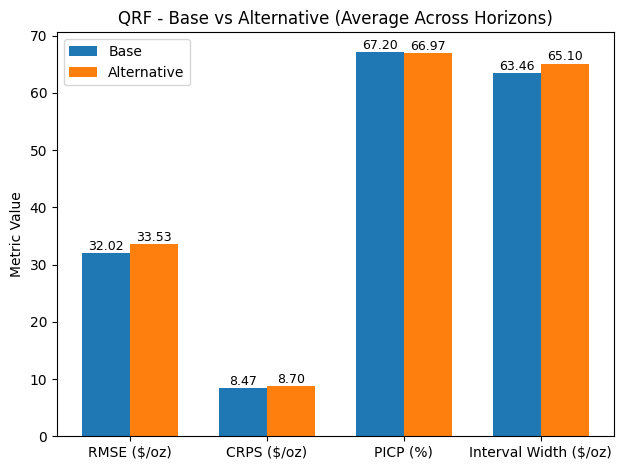

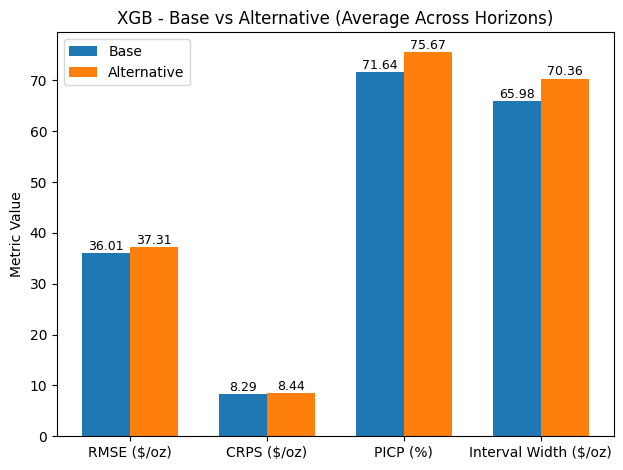

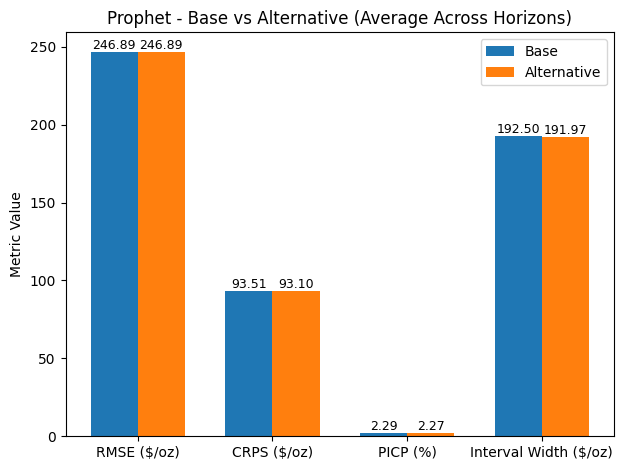

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Filter only average rows
avg_results = final_results[final_results["Horizon"] == "Average"].copy()

# Scale PICP to percentage
avg_results["PICP"] = avg_results["PICP"] * 100

metrics = ["RMSE", "CRPS", "PICP", "Interval_Width"]
metric_labels = ["RMSE ($/oz)", "CRPS ($/oz)", "PICP (%)", "Interval Width ($/oz)"]
models = ["QRF", "XGB", "Prophet"]

for model in models:
    
    model_data = avg_results[avg_results["Model"] == model]
    
    base_vals = model_data[model_data["Dataset"] == "Base"][metrics].values.flatten()
    alt_vals  = model_data[model_data["Dataset"] == "Alt"][metrics].values.flatten()
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.figure()
    
    bars_base = plt.bar(x - width/2, base_vals, width, label="Base")
    bars_alt  = plt.bar(x + width/2, alt_vals, width, label="Alternative")
    
    # Add value labels
    for i in range(len(metrics)):
        plt.text(x[i] - width/2, base_vals[i] + 0.01, f"{base_vals[i]:.2f}", ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + width/2, alt_vals[i] + 0.01, f"{alt_vals[i]:.2f}", ha='center', va='bottom', fontsize=9)
    
    plt.xticks(x, metric_labels)
    plt.title(f"{model} - Base vs Alternative (Average Across Horizons)")
    plt.legend()
    
    plt.ylabel("Metric Value")
    plt.tight_layout()
    plt.show()



Top 15 QRF Features (ALT dataset):


,Feature,Importance
12,Gold_MA_10,0.429496
0,Gold_Close,0.288875
3,Low,0.111044
2,High,0.094316
8,Gold_MA_5,0.035414
1,Open,0.014198
20,safe haven_MA_5,0.005018
11,USD_MA_5,0.003568
22,USD_Close_lag1,0.003290
15,USD_MA_10,0.002647


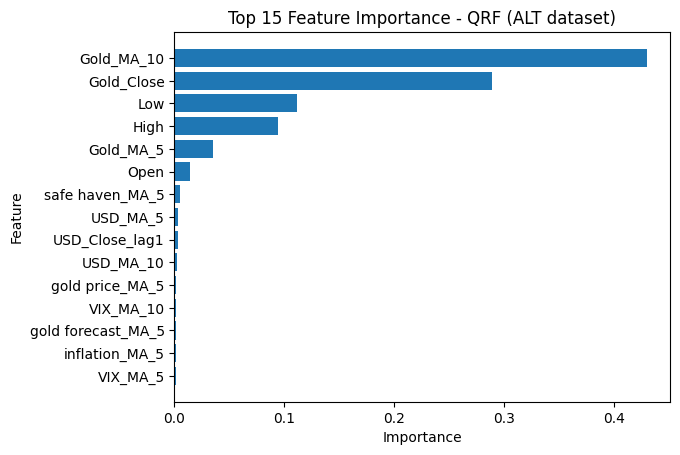


Top 15 XGBoost Features (ALT dataset):


,Feature,Importance
3,Low,38.819309
2,High,21.959339
0,Gold_Close,9.757862
12,Gold_MA_10,7.308669
8,Gold_MA_5,5.512166
14,VIX_MA_10,2.868884
1,Open,2.791083
11,USD_MA_5,2.784015
20,safe haven_MA_5,2.572266
15,USD_MA_10,2.518994


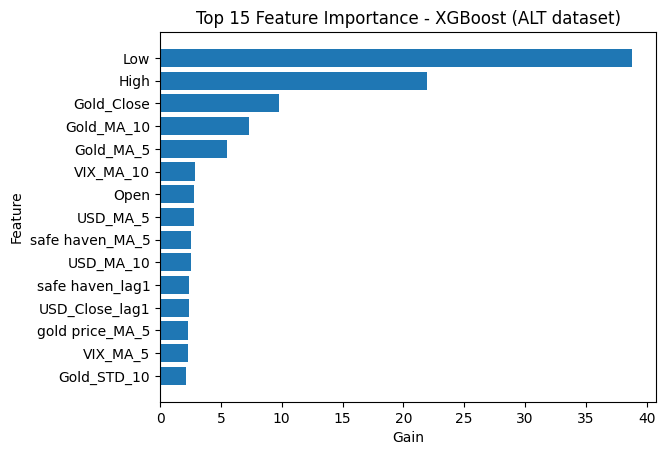

In [16]:
# ============================================
# FEATURE IMPORTANCE — ALT DATASET ONLY
# ============================================

# 1. Prepare ALT dataset
X_alt = alt_data.drop(
    columns=["Date"] + [f"Target_t+{i}" for i in range(1, HORIZON+1)]
)

y_alt = alt_data["Target_t+10"]

# Train/test split (same logic as before)
split_index = int(len(alt_data) * 0.8)

X_train_alt = X_alt.iloc[:split_index]
y_train_alt = y_alt.iloc[:split_index]

feature_cols = X_train_alt.columns.tolist()


# ============================================
# 2. QRF FEATURE IMPORTANCE
# ============================================

qrf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# IMPORTANT: keep feature names
qrf_model.fit(X_train_alt, y_train_alt)

qrf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": qrf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 QRF Features (ALT dataset):")
display(qrf_importance.head(15))

plt.figure()
plt.barh(qrf_importance["Feature"][:15][::-1],
         qrf_importance["Importance"][:15][::-1])
plt.title("Top 15 Feature Importance - QRF (ALT dataset)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# ============================================
# 3. XGBOOST FEATURE IMPORTANCE
# ============================================

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=0.5,  # median model
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train_alt, y_train_alt)

importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

# Map f0, f1 → actual feature names
feature_map = {f"f{i}": col for i, col in enumerate(feature_cols)}

xgb_importance = pd.DataFrame({
    "Feature": [feature_map.get(f, f) for f in importance_dict.keys()],
    "Importance": list(importance_dict.values())
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 XGBoost Features (ALT dataset):")
display(xgb_importance.head(15))

plt.figure()
plt.barh(xgb_importance["Feature"][:15][::-1],
         xgb_importance["Importance"][:15][::-1])
plt.title("Top 15 Feature Importance - XGBoost (ALT dataset)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.show()

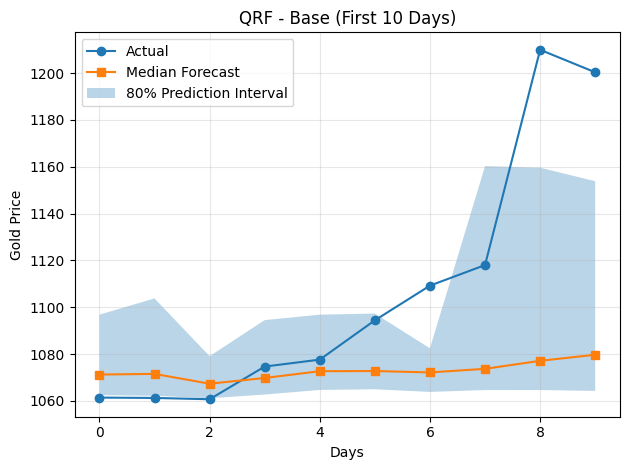

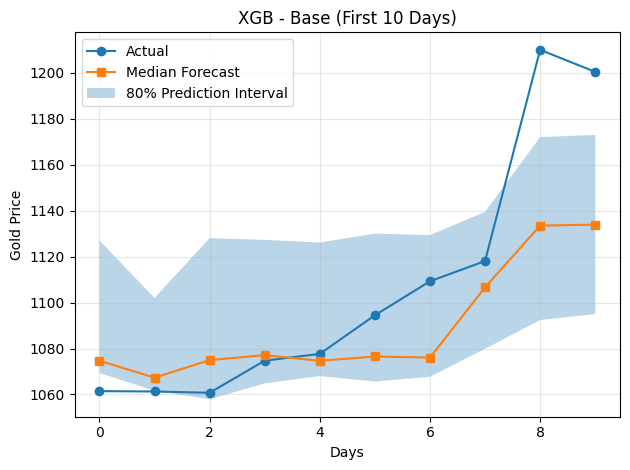

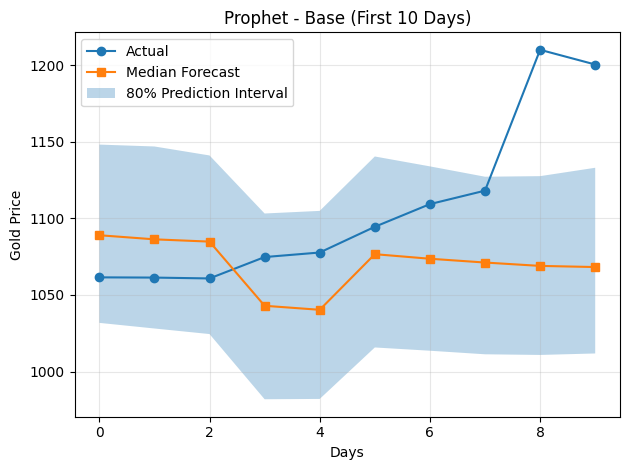

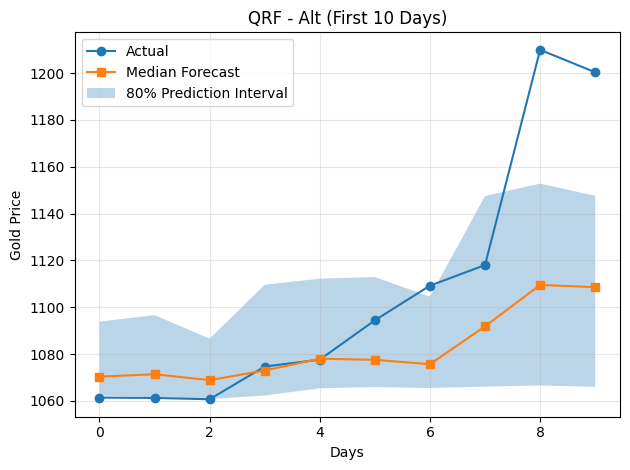

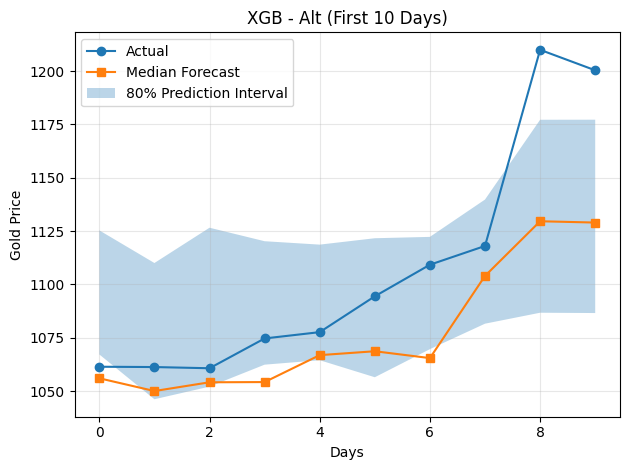

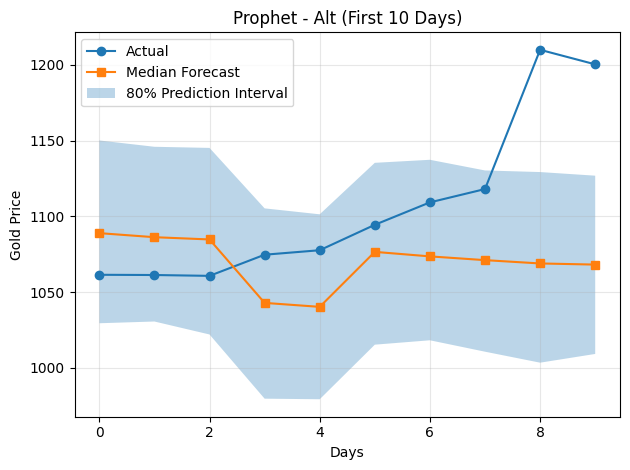

In [17]:

# ============================================
# FIRST 10 DAYS FORECAST COMPARISON
# ============================================

def plot_first_10(actual, preds, model_name, dataset_name):
    
    actual_first10 = actual[:10]
    lower = preds[0][:10]
    median = preds[1][:10]
    upper = preds[2][:10]
    
    plt.figure()
    plt.plot(actual_first10, label="Actual", marker='o')
    plt.plot(median, label="Median Forecast", marker='s')
    plt.fill_between(
        range(10),
        lower,
        upper,
        alpha=0.3,
        label="80% Prediction Interval"
    )
    
    plt.title(f"{model_name} - {dataset_name} (First 10 Days)")
    plt.xlabel("Days")
    plt.ylabel("Gold Price")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for dataset_name in ["Base", "Alt"]:
    
    y_test = results[dataset_name]["y_test"]
    
    for model in ["QRF", "XGB", "Prophet"]:
        
        preds = results[dataset_name][model]
        plot_first_10(y_test, preds, model, dataset_name)


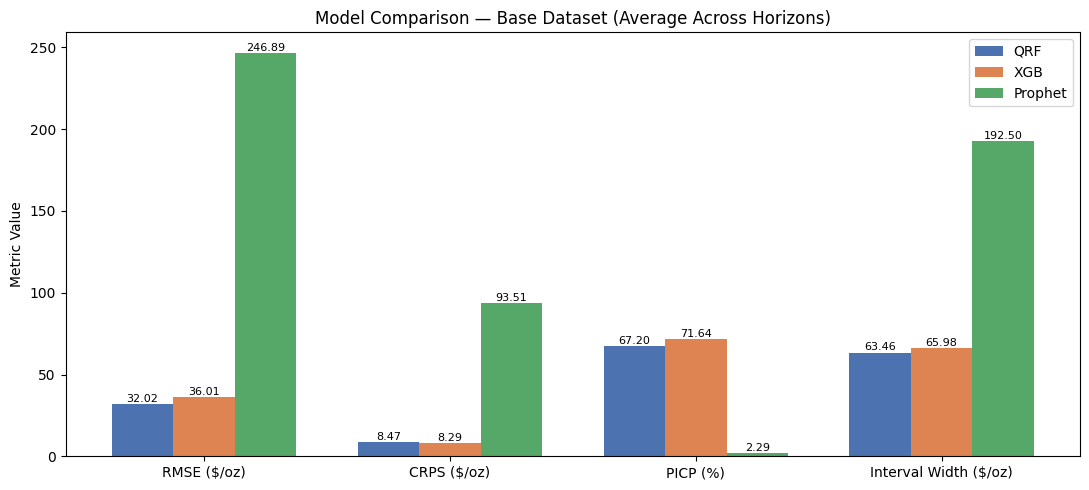

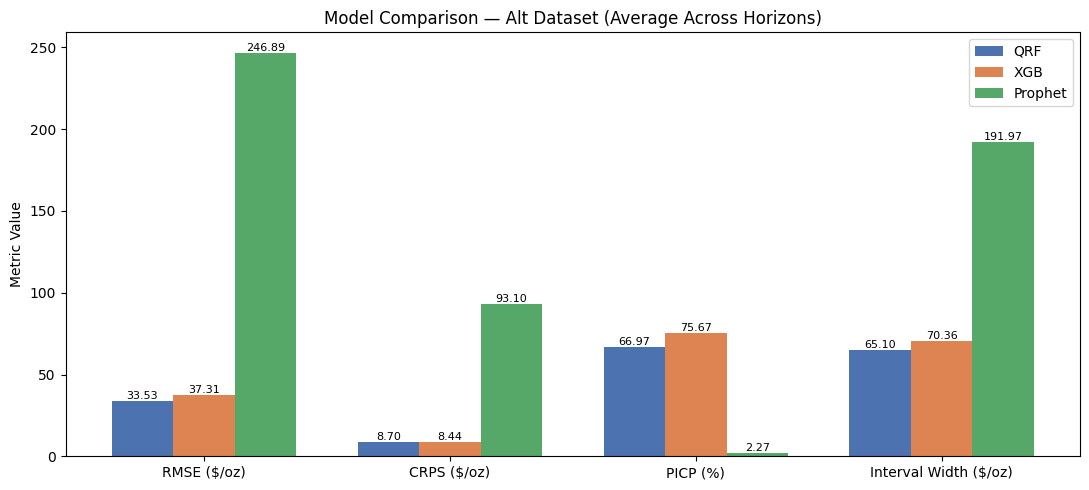

In [18]:
import matplotlib.pyplot as plt
import numpy as np

avg_results = final_results[final_results["Horizon"] == "Average"].copy()
avg_results["PICP"] = avg_results["PICP"] * 100

metrics = ["RMSE", "CRPS", "PICP", "Interval_Width"]
metric_labels = ["RMSE ($/oz)", "CRPS ($/oz)", "PICP (%)", "Interval Width ($/oz)"]
models = ["QRF", "XGB", "Prophet"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

x = np.arange(len(metrics))
width = 0.25

for dataset in ["Base", "Alt"]:

    dataset_data = avg_results[avg_results["Dataset"] == dataset]

    fig, ax = plt.subplots(figsize=(11, 5))

    for i, (model, color) in enumerate(zip(models, colors)):
        vals = dataset_data[dataset_data["Model"] == model][metrics].values.flatten()
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width, label=model, color=color)

        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel("Metric Value")
    ax.set_title(f"Model Comparison — {dataset} Dataset (Average Across Horizons)")
    ax.legend()
    plt.tight_layout()
    plt.show()
